In [43]:
import pandas as pd
import linearmodels as lm
from scipy.signal import find_peaks

data = pd.read_csv('ITSUR_data.csv')

data['begin_time'] = pd.to_datetime(data['begin_time'])


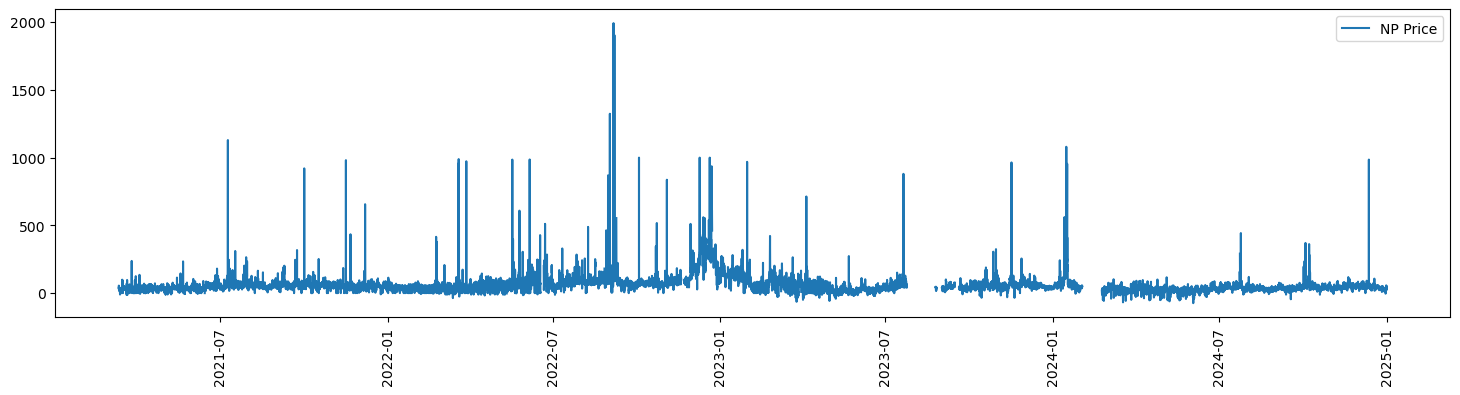

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 4))
#plt.plot(filtered_data['begin_time'], filtered_data['SP-15 LMP_da'] , label='SP Price')
plt.plot(data['begin_time'], data['NP-15 LMP_rt'] , label='NP Price')

plt.xticks(rotation=90)
plt.legend()
plt.show()

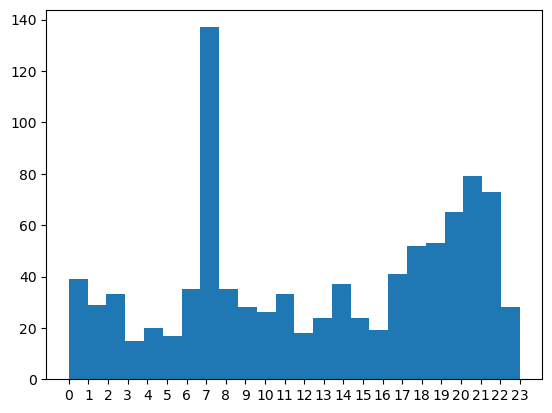

In [51]:
peaks = find_peaks(data['NP-15 LMP_rt'], height=100)
data.loc[peaks[0]]
plt.hist(data.loc[peaks[0]]['begin_time'].apply(lambda x: x.hour), bins=24)
plt.xticks(ticks=range(24))
plt.show()

In [52]:
data['NP-15 LMP_rt'].groupby(data['begin_time'].apply(lambda x: x.hour)).mean()

begin_time
0     59.777965
1     57.145862
2     55.065896
3     53.254319
4     52.208178
5     54.266949
6     61.217635
7     72.638351
8     55.871415
9     49.505281
10    46.820509
11    43.524567
12    41.570390
13    40.837130
14    42.154231
15    41.231230
16    44.702757
17    51.507632
18    62.879985
19    75.080072
20    75.665614
21    75.963839
22    71.974994
23    64.696336
Name: NP-15 LMP_rt, dtype: float64

In [ ]:
DailyNANCounts = data.groupby(data['begin_time'].apply(lambda x: x.date())).apply(lambda g: g.isna().sum())
DailyNANCounts.drop(columns=['begin_time'], inplace=True)
DailyNANCounts.reset_index(inplace=True)
DailyNANCounts

DailyNANCounts['NP-15 LMP_rt'].value_counts()
#Solar/Wind Generation and Real time prices have complicated gaps, others have simple gaps

NP-15 LMP_rt
0     1201
1       82
24      78
21      18
7        2
8        2
2        2
20       1
23       1
12       1
16       1
3        1
9        1
Name: count, dtype: int64

In [56]:
smallgapdays = DailyNANCounts['begin_time'][DailyNANCounts['NP-15 LMP_rt']<7].apply(lambda d: pd.date_range(start=pd.to_datetime(d), end=pd.to_datetime(d) + pd.Timedelta(hours=23), freq='h')).explode().reset_index(drop=True)
smallgapdays = smallgapdays.to_frame()

In [11]:
data_smallgaps = pd.merge(data, smallgapdays, on='begin_time', how='inner')
#bigrtgapfreedata[bigrtgapfreedata['begin_time'].apply(lambda x: x.date() == datetime.date(2024, 2, 23))]
#bigrtgapfreedata.loc[0]['begin_time'].date()

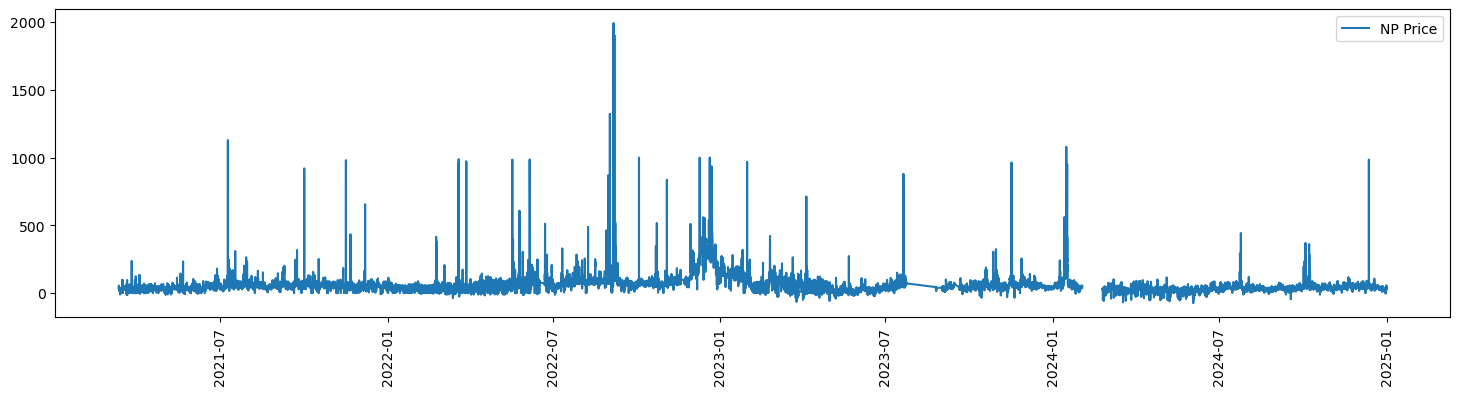

In [13]:
plt.figure(figsize=(18, 4))
#plt.plot(filtered_data['begin_time'], filtered_data['SP-15 LMP_da'] , label='SP Price')
plt.plot(data_smallgaps['begin_time'], data_smallgaps['NP-15 LMP_rt'] , label='NP Price')

plt.xticks(rotation=90)
plt.legend()
plt.show()

In [14]:
DailyNANCounts_postprocess = data_smallgaps.groupby(data_smallgaps['begin_time'].apply(lambda x: x.date())).apply(lambda g: g.isna().sum())
DailyNANCounts_postprocess.drop(columns=['begin_time'], inplace=True)
DailyNANCounts_postprocess.reset_index(inplace=True)
#DailyNANCounts_postprocess[DailyNANCounts_postprocess['NP-15 LMP_rt']==9]
DailyNANCounts_postprocess['NP-15 LMP_rt'].value_counts()

NP-15 LMP_rt
0    1201
1      82
2       2
3       1
Name: count, dtype: int64

In [26]:
data_nogaps = data_smallgaps.copy()
data_nogaps['NP-15 LMP_rt'] = data_smallgaps['NP-15 LMP_rt'].interpolate()
data_nogaps['NP-15 LMP_rt'].head(30)

0     34.56084
1     33.10504
2     34.53900
3     33.62841
4     34.56917
5     35.84329
6     55.49471
7     45.77074
8     27.37212
9     21.62038
10    19.98780
11    19.90433
12    20.96724
13    20.63653
14    25.80473
15    29.41729
16    17.95606
17    26.41758
18    39.57138
19    37.05668
20    33.03593
21    37.07234
22    38.13783
23    29.39887
24    27.40518
25    25.20116
26    22.46079
27    25.10775
28    25.55486
29    26.04807
Name: NP-15 LMP_rt, dtype: float64

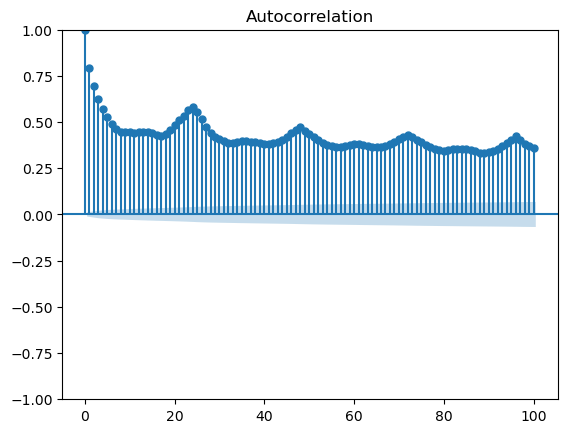

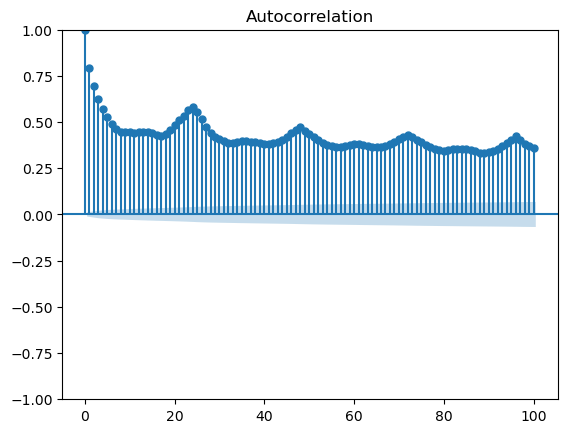

In [27]:
import statsmodels
import statsmodels.graphics
import statsmodels.graphics.tsaplots

statsmodels.graphics.tsaplots.plot_acf(data_nogaps['NP-15 LMP_rt'], lags=100)

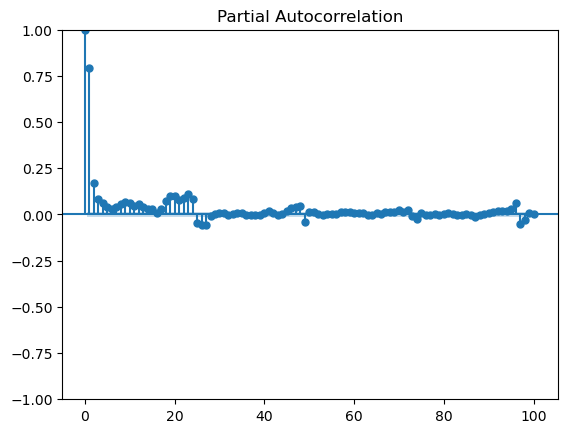

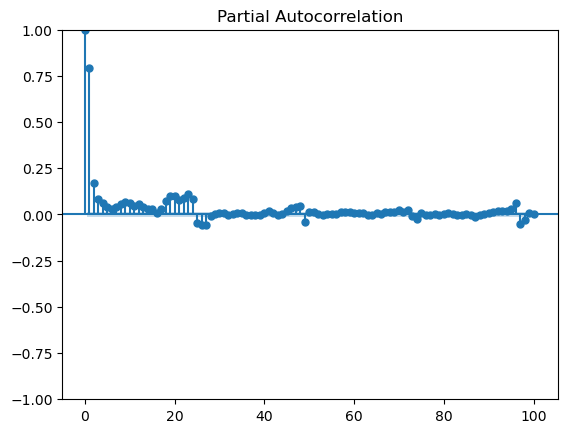

In [57]:
statsmodels.graphics.tsaplots.plot_pacf(data_nogaps['NP-15 LMP_rt'], lags=100)

In [29]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data_nogaps['NP-15 LMP_rt'], autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -9.162822898429177
p-value: 2.506252047179675e-15
Critical Values:
   1%: -3.4305622430420186
   5%: -2.8616338057784607
   10%: -2.5668199299374557


In [35]:
data_nogaps['NP-15 LMP_rt 24hrdiff'] = data_nogaps['NP-15 LMP_rt']-data_nogaps['NP-15 LMP_rt'].shift(24)
data_nogaps['NP-15 LMP_rt 24hrdiff'].head(50)
#data_nogaps

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9          NaN
10         NaN
11         NaN
12         NaN
13         NaN
14         NaN
15         NaN
16         NaN
17         NaN
18         NaN
19         NaN
20         NaN
21         NaN
22         NaN
23         NaN
24    -7.15566
25    -7.90388
26   -12.07821
27    -8.52066
28    -9.01431
29    -9.79522
30   -21.30799
31   -17.00372
32    -6.27900
33   -11.15081
34   -19.99900
35   -19.91566
36   -20.97819
37   -30.87705
38   -25.81556
39   -39.50283
40   -17.96663
41    -7.62106
42   -12.50667
43    -7.83614
44    -3.71053
45    -9.92122
46    -9.96841
47    -0.87359
48    -0.42333
49    -1.28234
Name: NP-15 LMP_rt 24hrdiff, dtype: float64

In [53]:
result = adfuller(data_nogaps['NP-15 LMP_rt 24hrdiff'].dropna(), autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -31.21400764365896
p-value: 0.0
Critical Values:
   1%: -3.4305624015998957
   5%: -2.861633875854317
   10%: -2.56681996723712


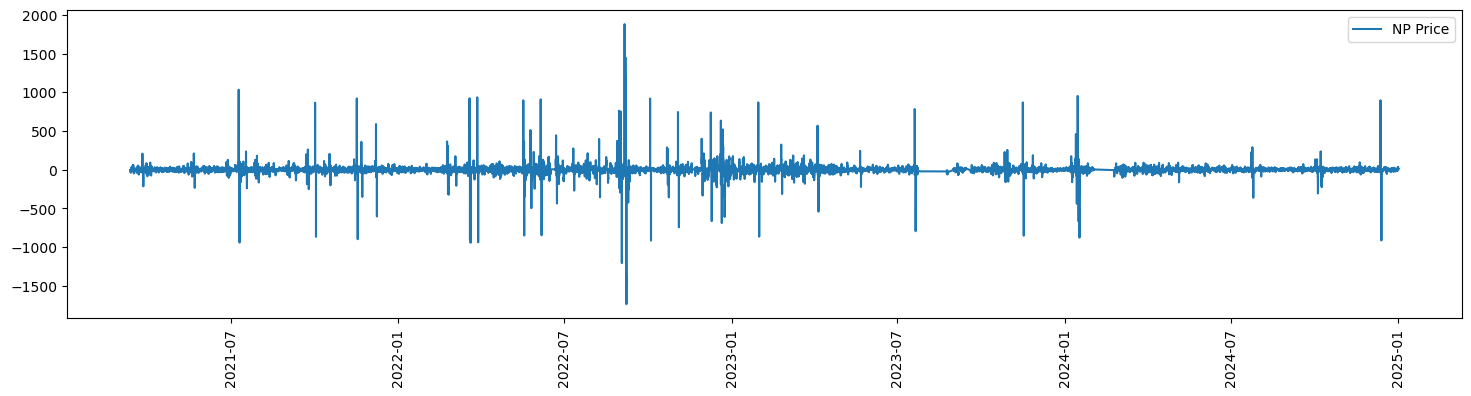

In [36]:
plt.figure(figsize=(18, 4))
plt.plot(data_nogaps['begin_time'], data_nogaps['NP-15 LMP_rt 24hrdiff'] , label='NP Price')

plt.xticks(rotation=90)
plt.legend()
plt.show()

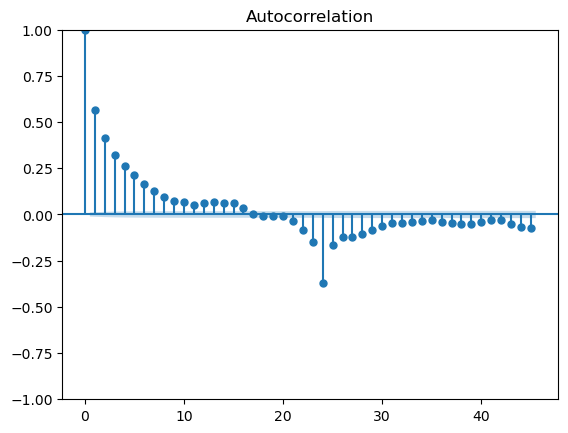

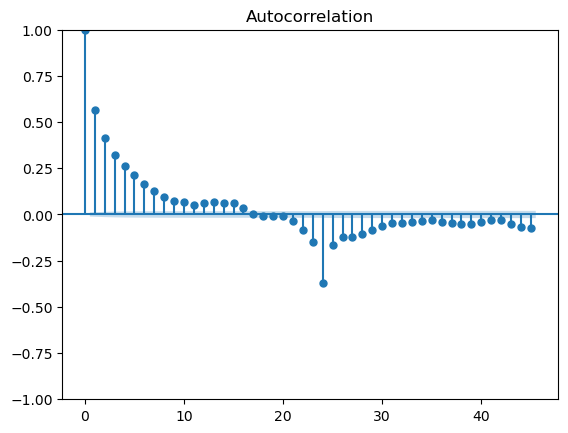

In [39]:
statsmodels.graphics.tsaplots.plot_acf(data_nogaps['NP-15 LMP_rt 24hrdiff'].dropna())

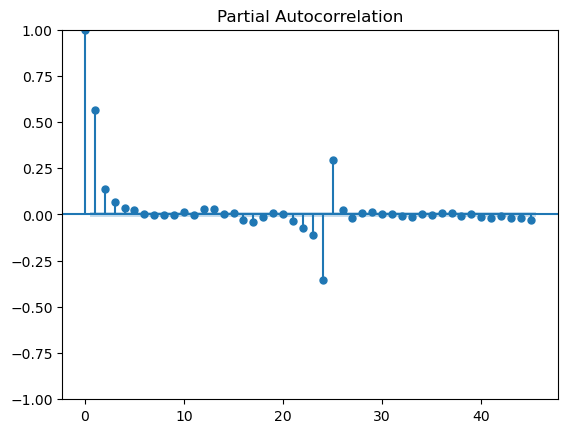

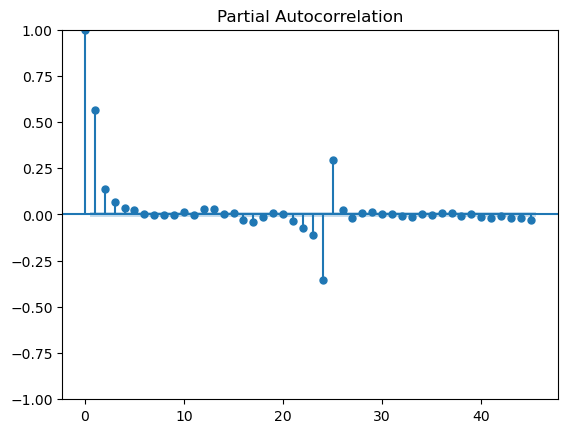

In [54]:
statsmodels.graphics.tsaplots.plot_pacf(data_nogaps['NP-15 LMP_rt 24hrdiff'].dropna())